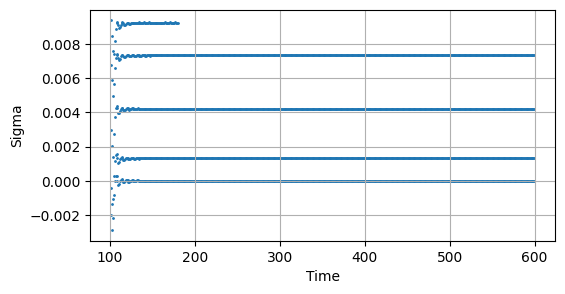

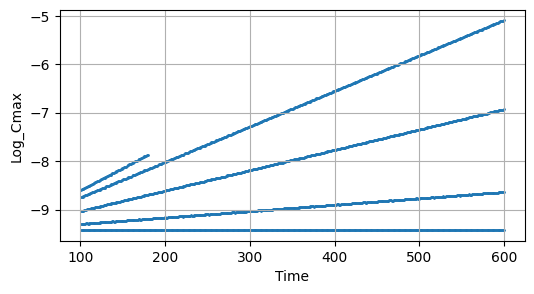

In [2]:
import pandas as pd
import os
from pathlib import Path
base=Path.cwd()
filesigma=base/'..'/'data_temporal'/'sigma.dat'
df_sigma=pd.read_csv(
    filesigma,
    header=None,
    sep='\s+',
    names=['time','sigma','log_cmax'])

import matplotlib.pyplot as plt

def scatter_plot(data_x,data_y,xlabel,ylabel):
    '''
    Parameters:
    x: variable x, str
    y: variable y, str

    '''
    plt.figure(figsize=(6,3))
    plt.scatter(data_x,data_y,s=1)
    plt.xlabel(xlabel.title());plt.ylabel(ylabel.title())
    plt.grid()
    plt.show()

scatter_plot(df_sigma['time'],df_sigma['sigma'],'time','sigma')
scatter_plot(df_sigma['time'],df_sigma['log_cmax'],'time','log_cmax')


In [105]:
files = Path('../data_temporal').glob('t*.dat')

dfs=[]
cols=['i',
      'a0l1','a0l2','a1l1','a1l2','a2l1','a2l2',
      'b0l1','b0l2','b1l1','b1l2','b2l1','b2l2']
for f in files: 
    df=pd.read_csv(
        f,
        header=None,
        sep='\s+',
        names=cols)
    t=int(f.stem.split('_')[-1]) #stem:name of the file without extension;name, suffix
    df['time']=t
    dfs.append(df)

df_all = pd.concat(dfs,ignore_index=True)

In [117]:
df2=df_all.copy()
cols=df2.filter(regex='^(a0|b0)l[1]$').columns
cols =['i', 'time', *cols]
time=[499]
df2=df2[df2['time'].isin(time)][cols]
df2

,i,time,a0l1,b0l1
5400,1,499,0.000000e+00,1.000000e+00
5401,2,499,2.168274e-32,1.000000e+00
5402,3,499,2.839708e-32,1.000000e+00
5403,4,499,3.959980e-32,1.000000e+00
5404,5,499,5.501763e-32,1.000000e+00
...,...,...,...,...
5995,596,499,1.000000e+00,5.817523e-44
5996,597,499,1.000000e+00,3.760007e-44
5997,598,499,1.000000e+00,2.174194e-44
5998,599,499,1.000000e+00,9.491542e-45


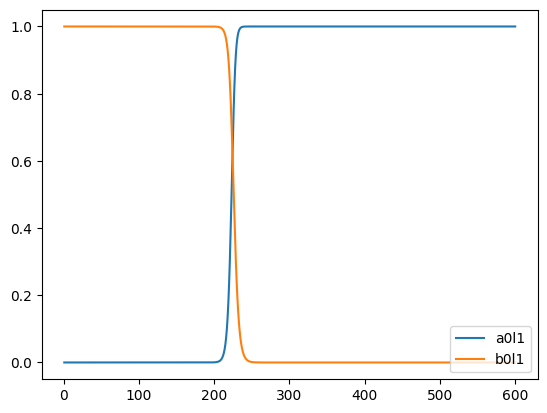

In [118]:
plt.plot(df2['i'],df2.iloc[:,2],label=df2.columns[2])
plt.plot(df2['i'],df2.iloc[:,3],label=df2.columns[3])
plt.legend(loc='lower right')
plt.show()